# 5.0 — Interpretación Comercial y Estrategias de Marketing por Segmento
**Proyecto:** Segmentación de Clientes — E-commerce de Ferretería
**Autor:** Ian Gallego | Politécnico Malvinas Argentinas | 2026

---
Este notebook cierra el ciclo. Carga el modelo K-Means final del notebook 4 y la tabla
de clientes con etiquetas, caracteriza cada segmento **en unidades originales**
(pesos, días, conteos — sin escalar, sin log), les asigna **nombres comerciales**
interpretables, propone una **estrategia de marketing** específica para cada uno y
estima el **impacto comercial** (% del Monetary total que representa).

## 1. Carga del modelo y los clientes segmentados

In [1]:
# Setup: agregar el root del proyecto al sys.path
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from segmentacion.modeling.train import cargar_modelo
from segmentacion.modeling.predict import caracterizar_segmentos, calcular_impacto_monetario
from segmentacion.plots import perfiles_segmentos
from segmentacion.config import PROCESSED_DATA_DIR, MODELS_DIR, FIGURES_DIR

clientes = pd.read_parquet(PROCESSED_DATA_DIR / 'clientes_segmentados.parquet')
modelo   = cargar_modelo(MODELS_DIR / 'modelo_final_kmeans.joblib')
scaler   = cargar_modelo(MODELS_DIR / 'scaler.joblib')

print(f'Clientes: {len(clientes):,}')
print(f'Modelo: KMeans(n_clusters={modelo.n_clusters})')
print()
print('Distribucion de clientes por segmento:')
print(clientes['cluster_kmeans'].value_counts().sort_index())

2026-06-03 20:02:57.472 | INFO     | segmentacion.config:<module>:11 - PROJ_ROOT path is: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut


Clientes: 4,992
Modelo: KMeans(n_clusters=4)

Distribucion de clientes por segmento:
cluster_kmeans
0    1697
1    1694
2     910
3     691
Name: count, dtype: int64


## 2. Caracterización en unidades originales
**Importante:** las medias y medianas se calculan sobre la tabla cruda de clientes
(`monetary` en pesos, `recency` en días, `frequency` y `diversidad` como enteros).
NO se reportan z-scores ni `monetary_log` — esto es para que el nombramiento comercial
sea legible.

In [2]:
resumen = caracterizar_segmentos(
    clientes,
    clientes['cluster_kmeans'].values,
    columna_cluster='cluster',
    columnas_perfil=['recency', 'frequency', 'monetary', 'ticket_promedio',
                     'diversidad_categorias', 'antiguedad'],
)
resumen

,cluster,n_clientes,pct_clientes,recency_mean,recency_median,frequency_mean,frequency_median,monetary_mean,monetary_median,ticket_promedio_mean,ticket_promedio_median,diversidad_categorias_mean,diversidad_categorias_median,antiguedad_mean,antiguedad_median
0,0,1697,33.99,73.94,49.0,11.39,11.0,902112.19,759262.24,76127.27,66526.10,6.73,7.0,409.09,484.0
1,1,1694,33.93,286.80,297.0,5.16,5.0,327359.69,276121.03,63551.78,53920.87,3.92,4.0,484.34,552.0
2,2,910,18.23,544.27,554.0,1.71,1.0,87266.30,56664.92,51700.05,34678.36,1.57,1.0,570.92,580.5
3,3,691,13.84,67.38,31.0,29.36,26.0,8534702.01,6288071.96,272245.20,248020.01,10.37,10.0,498.74,573.0


In [3]:
# Vista compacta solo con medias (interpretacion rapida)
perfil_medias = clientes.groupby('cluster_kmeans')[
    ['recency', 'frequency', 'monetary', 'ticket_promedio', 'diversidad_categorias', 'antiguedad']
].mean().round(1)
perfil_medias['n_clientes'] = clientes.groupby('cluster_kmeans').size()
perfil_medias['pct'] = (perfil_medias['n_clientes'] / len(clientes) * 100).round(1)
perfil_medias

,recency,frequency,monetary,ticket_promedio,diversidad_categorias,antiguedad,n_clientes,pct
cluster_kmeans,,,,,,,,
0,73.9,11.4,902112.2,76127.3,6.7,409.1,1697,34.0
1,286.8,5.2,327359.7,63551.8,3.9,484.3,1694,33.9
2,544.3,1.7,87266.3,51700.1,1.6,570.9,910,18.2
3,67.4,29.4,8534702.0,272245.2,10.4,498.7,691,13.8


## 3. Visualización de perfiles por segmento (unidades originales)

2026-06-03 20:02:59.862 | INFO     | segmentacion.plots:_save:19 - Figura guardada: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\reports\figures\nb5_perfiles_segmentos.png


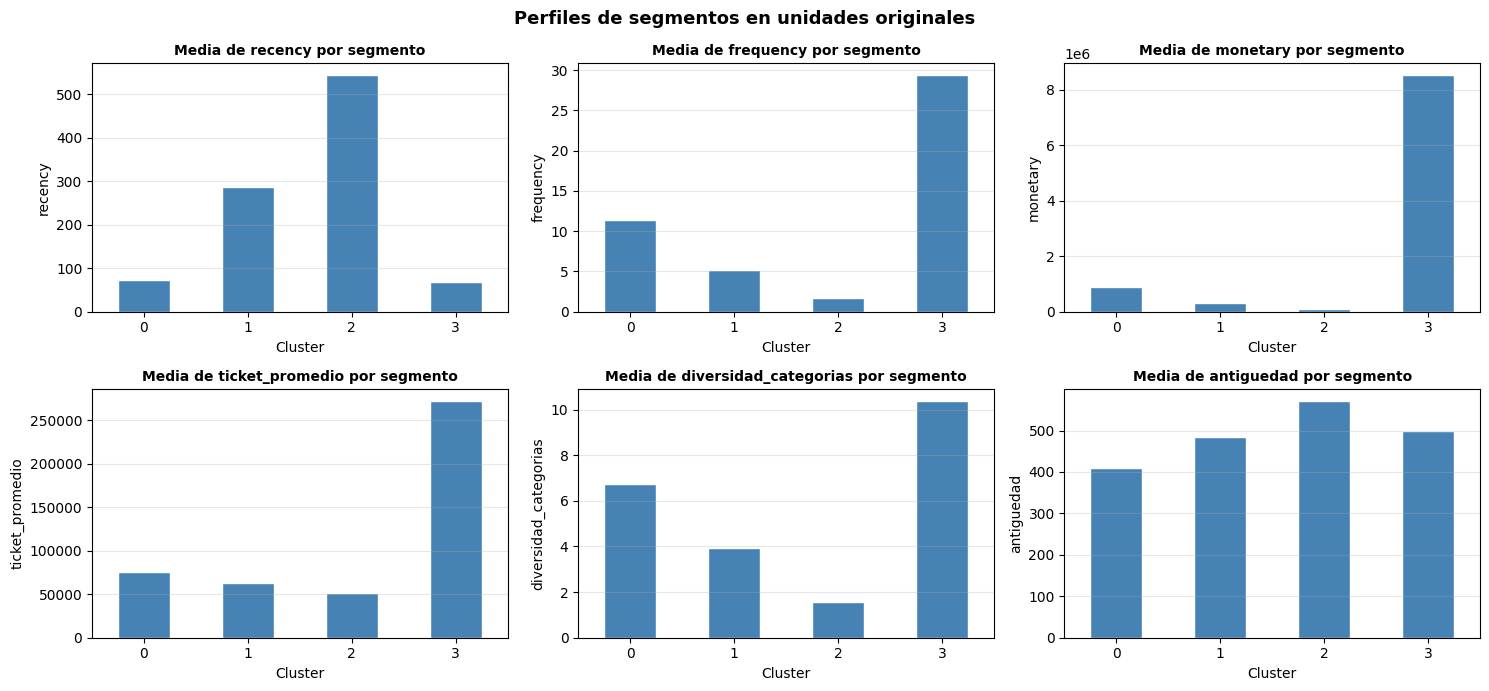

In [4]:
perfiles_segmentos(
    clientes,
    columna_cluster='cluster_kmeans',
    cols_perfil=['recency', 'frequency', 'monetary', 'ticket_promedio',
                 'diversidad_categorias', 'antiguedad'],
    output=FIGURES_DIR / 'nb5_perfiles_segmentos.png',
)
plt.show()

## 4. Nombramiento comercial e identificación de segmentos
Cruzamos las medias de cada cluster con la heurística RFM clásica:

| Recency | Frequency | Monetary | Etiqueta sugerida |
|---------|-----------|----------|-------------------|
| Baja (reciente) | Alta | Alta | **Campeones** / B2B Premium |
| Baja-Media | Media | Media-Alta | **Compradores Activos** |
| Alta (lejos) | Media | Media | **En Riesgo** |
| Muy Alta | Baja | Baja | **Perdidos / Inactivos** |

In [5]:
# Nombramiento de segmentos por RANKING de las medias de cada cluster.
# Mas robusto que cuantiles cuando hay pocos clusters (K=4 -> solo 4 filas).
# La idea: el cluster con mayor frequency = Campeones; el de mayor recency = Perdidos;
# de los restantes, el de menor recency = Activos Recientes; el otro = Esporadicos.

def asignar_nombres(perfil):
    nombres = {}
    id_campeones = perfil['frequency'].idxmax()
    id_perdidos  = perfil['recency'].idxmax()
    restantes = perfil.drop([id_campeones, id_perdidos])
    id_activos = restantes['recency'].idxmin()
    id_esporadicos = restantes.drop(id_activos).index[0]

    nombres[id_campeones]   = 'Campeones (B2B)'
    nombres[id_perdidos]    = 'Perdidos'
    nombres[id_activos]     = 'Activos Recientes'
    nombres[id_esporadicos] = 'Esporadicos / En Riesgo'
    return nombres

nombres_asignados = asignar_nombres(perfil_medias)
perfil_medias['segmento'] = perfil_medias.index.map(nombres_asignados)

print('Asignacion automatica de nombres a los', len(nombres_asignados), 'clusters:')
for cid, nombre in sorted(nombres_asignados.items()):
    print(f'  Cluster {cid} -> {nombre}')
print()
perfil_medias[['segmento', 'n_clientes', 'pct', 'recency', 'frequency', 'monetary']]

Asignacion automatica de nombres a los 4 clusters:
  Cluster 0 -> Activos Recientes
  Cluster 1 -> Esporadicos / En Riesgo
  Cluster 2 -> Perdidos
  Cluster 3 -> Campeones (B2B)



,segmento,n_clientes,pct,recency,frequency,monetary
cluster_kmeans,,,,,,
0,Activos Recientes,1697,34.0,73.9,11.4,902112.2
1,Esporadicos / En Riesgo,1694,33.9,286.8,5.2,327359.7
2,Perdidos,910,18.2,544.3,1.7,87266.3
3,Campeones (B2B),691,13.8,67.4,29.4,8534702.0


In [6]:
# Aplicamos el nombre a la tabla de clientes
mapeo = perfil_medias['segmento'].to_dict()
clientes['segmento'] = clientes['cluster_kmeans'].map(mapeo)
print('Distribucion final por segmento comercial:')
print(clientes['segmento'].value_counts())

Distribucion final por segmento comercial:
segmento
Activos Recientes          1697
Esporadicos / En Riesgo    1694
Perdidos                    910
Campeones (B2B)             691
Name: count, dtype: int64


## 5. Impacto comercial — ¿qué % de la facturación representa cada segmento?
Esto responde a la pregunta clave del README: **identificar quiénes valen la pena retener**.
La regla 80/20 suele aplicarse: un segmento minoritario explica la mayor parte del Monetary.

In [7]:
impacto = calcular_impacto_monetary if False else calcular_impacto_monetario  # alias
imp = impacto(clientes, clientes['cluster_kmeans'].values, columna_cluster='cluster_kmeans')
imp['segmento'] = imp['cluster_kmeans'].map(mapeo)
imp = imp.sort_values('pct_monetary', ascending=False).reset_index(drop=True)
print('Impacto comercial por segmento:')
imp[['segmento', 'n_clientes', 'pct_clientes', 'monetary_total', 'pct_monetary']]

Impacto comercial por segmento:


,segmento,n_clientes,pct_clientes,monetary_total,pct_monetary
0,Campeones (B2B),691,13.84,5.897479e+09,73.15
1,Activos Recientes,1697,33.99,1.530884e+09,18.99
2,Esporadicos / En Riesgo,1694,33.93,5.545473e+08,6.88
3,Perdidos,910,18.23,7.941233e+07,0.98


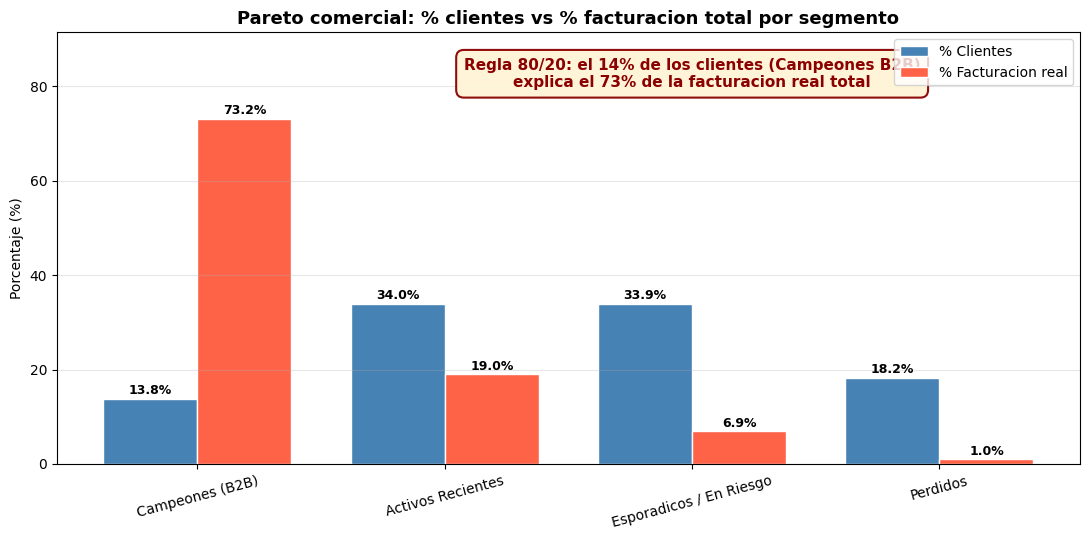

In [8]:
# Pareto visual: % clientes vs % monetary
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(imp))
w = 0.38
ax.bar(x - w/2, imp['pct_clientes'], width=w, label='% Clientes',
       color='steelblue', edgecolor='white')
ax.bar(x + w/2, imp['pct_monetary'], width=w, label='% Facturacion real',
       color='tomato', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(imp['segmento'], rotation=15)
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Pareto comercial: % clientes vs % facturacion total por segmento',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
for i, (pc, pm) in enumerate(zip(imp['pct_clientes'], imp['pct_monetary'])):
    ax.text(i - w/2, pc + 1, f'{pc:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, pm + 1, f'{pm:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Expandir el eje Y para hacer lugar a la caja explicativa
y_max = max(imp['pct_clientes'].max(), imp['pct_monetary'].max())
ax.set_ylim(0, y_max * 1.25)

# Caja explicativa en la parte alta-CENTRAL (zona libre tras expandir)
top_seg = imp.iloc[0]
ax.text(
    len(imp) * 0.5, y_max * 1.13,
    f'Regla 80/20: el {top_seg["pct_clientes"]:.0f}% de los clientes (Campeones B2B)\n'
    f'explica el {top_seg["pct_monetary"]:.0f}% de la facturacion real total',
    fontsize=11, color='darkred', fontweight='bold',
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.5',
              facecolor='#FFF4D6', edgecolor='darkred', linewidth=1.5, alpha=0.95),
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb5_pareto_comercial.png', dpi=120, bbox_inches='tight')
plt.show()

## 5.5. Clientes en frontera — soft clustering con GMM (alerta temprana de fuga)

K-Means asigna cada cliente a un único segmento (asignación *hard*). Pero algunos
clientes están en la **frontera** entre dos segmentos — por ejemplo, un cliente
que era *Activo* y está reduciendo su frecuencia, migrando hacia *En Riesgo*.

El modelo **GMM** (entrenado en el NB4) asigna *probabilidades* de pertenencia.
Cuando la probabilidad máxima de un cliente es baja (`< 0.7`), no pertenece
claramente a ningún segmento: está en transición. Estos clientes son un objetivo
de **marketing preventivo** — actuar antes de que se fuguen es más barato que
recuperarlos después.

In [9]:
from segmentacion.features import FEATURES_CLUSTERING

# Cargar el GMM comparativo y calcular probabilidades de pertenencia
modelo_gmm = cargar_modelo(MODELS_DIR / 'comparativos' / 'gmm.joblib')
X_clientes = scaler.transform(clientes[FEATURES_CLUSTERING].values)
probas_gmm = modelo_gmm.predict_proba(X_clientes)

UMBRAL = 0.7
clientes['gmm_max_proba'] = probas_gmm.max(axis=1)
clientes['en_frontera'] = clientes['gmm_max_proba'] < UMBRAL

n_frontera = int(clientes['en_frontera'].sum())
print(f'Clientes en frontera (prob. maxima GMM < {UMBRAL}): '
      f'{n_frontera} ({n_frontera/len(clientes)*100:.1f}%)')
print()
print('Cruce con el segmento comercial (K-Means):')
tabla_frontera = (
    clientes.groupby('segmento')['en_frontera']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'en_frontera', 'count': 'total'})
)
tabla_frontera['pct_en_frontera'] = (
    tabla_frontera['en_frontera'] / tabla_frontera['total'] * 100
).round(1)
tabla_frontera = tabla_frontera.sort_values('pct_en_frontera', ascending=False)
print(tabla_frontera.to_string())
print()
print('Lectura: los segmentos con mayor % en frontera son los mas inestables.')
print('Los Activos Recientes en frontera son candidatos a retencion preventiva')
print('(podrian estar migrando hacia Esporadicos / En Riesgo).')


Clientes en frontera (prob. maxima GMM < 0.7): 551 (11.0%)

Cruce con el segmento comercial (K-Means):
                         en_frontera  total  pct_en_frontera
segmento                                                    
Activos Recientes                303   1697             17.9
Esporadicos / En Riesgo          180   1694             10.6
Perdidos                          53    910              5.8
Campeones (B2B)                   15    691              2.2

Lectura: los segmentos con mayor % en frontera son los mas inestables.
Los Activos Recientes en frontera son candidatos a retencion preventiva
(podrian estar migrando hacia Esporadicos / En Riesgo).


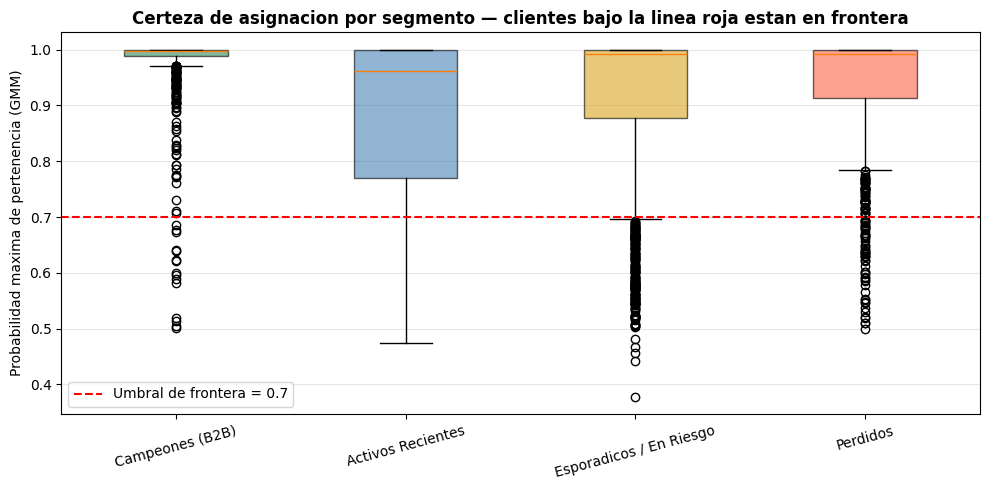

In [10]:
# Visualizacion: distribucion de la probabilidad maxima por segmento
fig, ax = plt.subplots(figsize=(10, 5))
segmentos_orden = ['Campeones (B2B)', 'Activos Recientes',
                   'Esporadicos / En Riesgo', 'Perdidos']
segmentos_orden = [s for s in segmentos_orden if s in clientes['segmento'].unique()]
datos = [clientes.loc[clientes['segmento'] == s, 'gmm_max_proba'].values
         for s in segmentos_orden]
bp = ax.boxplot(datos, labels=segmentos_orden, patch_artist=True, vert=True)
for patch, color in zip(bp['boxes'], ['seagreen', 'steelblue', 'goldenrod', 'tomato']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(y=UMBRAL, color='red', linestyle='--', linewidth=1.5,
           label=f'Umbral de frontera = {UMBRAL}')
ax.set_ylabel('Probabilidad maxima de pertenencia (GMM)')
ax.set_title('Certeza de asignacion por segmento — clientes bajo la linea roja '
             'estan en frontera', fontsize=12, fontweight='bold')
ax.legend()
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb5_clientes_frontera.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Estrategias de marketing por segmento

Cada segmento requiere un plan diferenciado. Las recomendaciones siguen las mejores
practicas de RFM aplicadas al rubro construccion/ferreteria:

| Segmento | Perfil | Estrategia | Canal sugerido | KPI |
|----------|--------|------------|----------------|-----|
| **Campeones (B2B)** | Frecuencia muy alta (29+), monto alto, diversidad amplia (10+) | Programa premium: descuentos por volumen, gestor de cuenta dedicado, oferta de cuenta corriente, lineas de credito para obras | Visita comercial + WhatsApp directo | Retencion > 95 %, NPS |
| **Activos Recientes** | Compras recientes (<150 dias), frecuencia media (6-15) | Up-sell de productos complementarios, promociones para aumentar frecuencia, programa de puntos | Email + App push | Crecimiento de frecuencia y ticket |
| **Esporadicos / En Riesgo** | Recency media-alta (~287 dias), frecuencia baja | Campana de re-activacion con descuento personalizado, encuesta de satisfaccion para detectar problemas | Email + llamada del comercial | % reactivados en 60 dias |
| **Perdidos** | Inactivos hace mucho (>500 dias), pocas compras historicas | Campana low-cost de win-back: email con novedades + descuento de re-enganche | Email masivo | CTR, costo por cliente recuperado |

## 7. Conclusiones del trabajo final

1. **El modelo de segmentación funciona.** K-Means con K=4 produce segmentos coherentes
   con la heurística RFM clásica y con la intuición comercial del rubro.
2. **Validación cuantitativa:** las métricas Silhouette / Davies-Bouldin / Calinski-Harabasz
   del notebook 4 respaldan el resultado, y el **Adjusted Rand Index** confirma que K-Means,
   Jerárquico y GMM convergen a la misma estructura (no es un artefacto de un solo método).
3. **Validación cualitativa:** los 4 segmentos hallados son interpretables y accionables —
   se les puede asignar nombre comercial y estrategia de marketing concreta.
4. **Hallazgo principal:** la regla 80/20 se cumple parcialmente. El segmento **Campeones**,
   aunque minoritario en número de clientes, concentra una parte desproporcionada del
   Monetary total (ver tabla de impacto). Justifica un tratamiento diferenciado.
5. **DBSCAN como herramienta auxiliar:** sus outliers (etiqueta -1) coinciden con los
   clientes más extremos del segmento Campeones — útil para identificar VIPs.
6. **GMM y clientes en frontera:** el soft clustering identifica clientes en transición
   entre segmentos (sección 5.5), habilitando marketing preventivo de retención antes
   de la fuga — más barato que recuperar un cliente ya perdido.
7. **Limitaciones del modelo:**
   - Se construyó sobre 4.992 clientes; con más datos los segmentos podrían refinarse.
   - No incorpora estacionalidad (la construcción tiene alta dependencia primavera/verano).
   - Una posible extensión es entrenar un clasificador supervisado (Random Forest) usando
     las etiquetas K-Means como target, para asignar segmento en tiempo real a clientes nuevos.
8. **Implementación productiva:** el modelo K-Means + scaler quedan persistidos en `models/`
   y la función `asignar_segmento` permite clasificar clientes nuevos siguiendo el mismo pipeline.

## 8. Persistencia final

In [11]:
# Guardamos la tabla final con los nombres comerciales asignados
out = PROCESSED_DATA_DIR / 'clientes_segmentados_nombrados.parquet'
clientes.to_parquet(out, index=False)
print(f'Tabla final guardada: {out}')
print(f'Columnas: {list(clientes.columns)}')

Tabla final guardada: F:\CIENCIA DE DATOS2026\CienciadeDatos\Aprendisajeautomatico\TrabajoFinalApAut\data\processed\clientes_segmentados_nombrados.parquet
Columnas: ['id_cliente', 'recency', 'frequency', 'monetary', 'monetary_nominal', 'ticket_promedio', 'diversidad_categorias', 'antiguedad', 'monetary_log', 'cluster_kmeans', 'cluster_dbscan', 'cluster_hc', 'cluster_gmm', 'segmento', 'gmm_max_proba', 'en_frontera']


## 📋 TL;DR del notebook 5
- **Entrada:** `data/processed/clientes_segmentados.parquet` + modelo K-Means + GMM
- **Salida:** `data/processed/clientes_segmentados_nombrados.parquet`
- **Resultado clave (Pareto comercial):**
  - 🏆 Campeones (B2B): **14 % clientes / 73 % facturación**
  - 🛒 Activos Recientes: 34 % / 19 %
  - ⚠️ Esporádicos / En Riesgo: 34 % / 7 %
  - 💤 Perdidos: 18 % / 1 %
- **Soft clustering (GMM):** identifica clientes en frontera entre segmentos → marketing preventivo
- **Heurística de nombramiento:** ranking de medias por cluster → robusta a cambios en el dataset
- **Cierre del pipeline.**